# 04 - Index construction (ALI 2022)

This notebook:
- applies direction rules (higher=better)
- applies log transforms to skewed indicators (GDP per capita, PPP conversion factor)
- normalises indicators to 0–100 using min–max scaling
- builds sub-indices (pillars) and the final ALI composite index
- produces ranking tables and exports data for visualisation

Inputs:
- `data/processed/ali_2022_imputed.csv`
- `data/processed/ali_2022_with_clusters.csv`

Outputs:
- `data/processed/ali_2022_index.csv`
- figures saved to `outputs/figures/`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/ali_2022_imputed.csv")

# Attach cluster labels
try:
    cl = pd.read_csv("../data/processed/ali_2022_with_clusters.csv")[["iso3", "cluster"]]
    df = df.merge(cl, on="iso3", how="left")
except FileNotFoundError:
    df["cluster"] = np.nan

df.head(), df.shape

(       country iso3  year  gdp_per_capita_ppp_const  unemployment_rate  \
 0        Aruba  ABW  2022              38979.835825           5.512170   
 1  Afghanistan  AFG  2022               1981.710168          14.100000   
 2       Angola  AGO  2022               8950.142593          14.124000   
 3      Albania  ALB  2022              19388.873133          10.785000   
 4      Andorra  AND  2022              63913.383508          11.149912   
 
    labor_force_participation  life_expectancy  ppp_conversion_factor  cluster  
 0                  60.761253           76.226               1.327790        1  
 1                  37.640000           65.617              14.897971        0  
 2                  75.247000           64.246             191.953512        2  
 3                  62.161000           78.769              39.608065        3  
 4                  54.375607           84.016               0.588248        1  ,
 (209, 9))

In [4]:
# log1p reduces the impact of extreme outliers and skew
df = df.copy()
df["gdp_pc_log"] = np.log1p(df["gdp_per_capita_ppp_const"])
df["ppp_conv_log"] = np.log1p(df["ppp_conversion_factor"])

df[["gdp_per_capita_ppp_const", "gdp_pc_log", "ppp_conversion_factor", "ppp_conv_log"]].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_per_capita_ppp_const,209.0,26656.150004,26177.782345,1031.254122,6418.174984,17119.574495,39864.010088,133571.962410
gdp_pc_log,209.0,9.650446,1.140894,6.939500,8.767045,9.748036,10.593254,11.802403
ppp_conversion_factor,209.0,630.143802,5037.720877,0.085160,0.918072,4.624378,84.098765,71200.145632
ppp_conv_log,209.0,2.612557,2.383369,0.081727,0.651321,1.727110,4.443813,11.173264


In [5]:
# Direction: +1 means higher is better, -1 means higher is worse (reverse-coded)
DIRECTION = {
    "gdp_pc_log": +1,
    "unemployment_rate": -1,
    "labor_force_participation": +1,
    "life_expectancy": +1,
    "ppp_conv_log": -1  # higher cost pressure proxy is worse = reverse
}

def minmax_0_100(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    xmin, xmax = x.min(), x.max()
    if np.isclose(xmax, xmin):
        return pd.Series(np.full(len(x), 50.0), index=x.index)
    return (x - xmin) / (xmax - xmin) * 100

In [6]:
df_dir = df.copy()

# Reverse “bad when higher” by multiplying by -1 before scaling
for col, sign in DIRECTION.items():
    if sign == -1:
        df_dir[col] = -df_dir[col]

norm_cols = []
for col in DIRECTION.keys():
    out = col + "_norm"
    df_dir[out] = minmax_0_100(df_dir[col])
    norm_cols.append(out)

df_dir[["country","iso3"] + norm_cols].head()

,country,iso3,gdp_pc_log_norm,unemployment_rate_norm,labor_force_participation_norm,life_expectancy_norm,ppp_conv_log_norm
0,Aruba,ABW,74.674022,85.190222,58.146681,85.824488,93.119150
1,Afghanistan,AFG,13.422431,61.559628,22.056941,69.964120,75.797184
2,Angola,AGO,44.418659,61.493589,80.757344,67.914486,53.291216
3,Albania,ALB,60.313892,70.681305,60.331533,89.626252,67.342313
4,Andorra,AND,84.842317,69.677199,48.179389,97.470474,96.565810


In [7]:
# Cost Pressure (CP): based on log PPP conversion factor (reverse-coded then scaled)
df_dir["CP"] = df_dir["ppp_conv_log_norm"]

# Economic Opportunity (EO): log income + labour market indicators
df_dir["EO"] = df_dir[
    ["gdp_pc_log_norm", "unemployment_rate_norm", "labor_force_participation_norm"]
].mean(axis=1)

# Quality of Life (QOL): life expectancy only
df_dir["QOL"] = df_dir["life_expectancy_norm"]

df_dir[["CP","EO","QOL"]].describe().T

,count,mean,std,min,25%,50%,75%,max
CP,209.0,77.182337,21.488178,0.000000,60.671949,85.165418,94.864611,100.000000
EO,209.0,64.563242,12.390192,23.373143,57.261961,65.776981,73.815655,98.958311
QOL,209.0,80.747518,11.844841,0.000000,73.040813,82.683510,88.343549,100.000000


In [8]:
w_CP, w_EO, w_QOL = 1/3, 1/3, 1/3
df_dir["ALI"] = w_CP*df_dir["CP"] + w_EO*df_dir["EO"] + w_QOL*df_dir["QOL"]
df_dir["ALI_rank"] = df_dir["ALI"].rank(ascending=False, method="min").astype(int)

df_dir.sort_values("ALI", ascending=False).head(15)[
    ["ALI_rank","country","iso3","ALI","CP","EO","QOL","cluster"]
]

,ALI_rank,country,iso3,ALI,CP,EO,QOL,cluster
156,1,Qatar,QAT,94.107537,89.121514,98.958311,94.242787,1
163,2,Singapore,SGP,92.810383,95.093464,87.542913,95.794770,1
18,3,Bahrain,BHR,92.114896,99.200722,84.194347,92.949619,1
103,4,Kuwait,KWT,92.001814,98.925926,84.734165,92.345350,1
87,5,Ireland,IRL,91.498136,95.839860,83.435897,95.218652,1
32,6,Switzerland,CHE,91.265568,94.546698,82.394155,96.855850,1
112,7,Luxembourg,LUX,91.104282,95.439070,82.002434,95.871343,1
137,8,Netherlands,NLD,90.585893,95.878627,81.998599,93.880452,1
123,9,Malta,MLT,90.150366,96.735837,78.813838,94.901422,1
9,10,Australia,AUS,89.901959,93.000115,80.455201,96.250561,1


In [9]:
# Keep normalized indicators too (for transparency)
out = df_dir[[
    "country","iso3","year","cluster",
    "ALI","ALI_rank","CP","EO","QOL"
] + norm_cols].copy()

OUT_PATH = "../data/processed/ali_2022_index.csv"
out.to_csv(OUT_PATH, index=False)

OUT_PATH, out.shape

('../data/processed/ali_2022_index.csv', (209, 14))

'../outputs/figures/ali_top20.png'

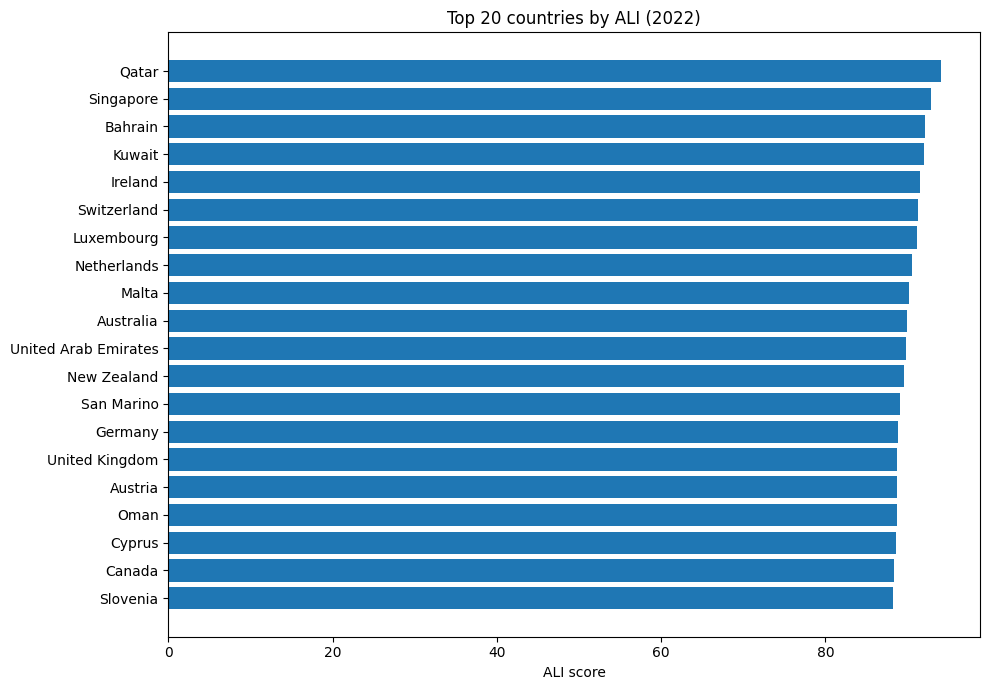

In [10]:
topn = 20
plot_df = out.sort_values("ALI", ascending=False).head(topn).sort_values("ALI")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["country"], plot_df["ALI"])
plt.title(f"Top {topn} countries by ALI (2022)")
plt.xlabel("ALI score")
plt.tight_layout()

fig_path = "../outputs/figures/ali_top20.png"
plt.savefig(fig_path, dpi=200)
fig_path

'../outputs/figures/scatter_eo_vs_cp.png'

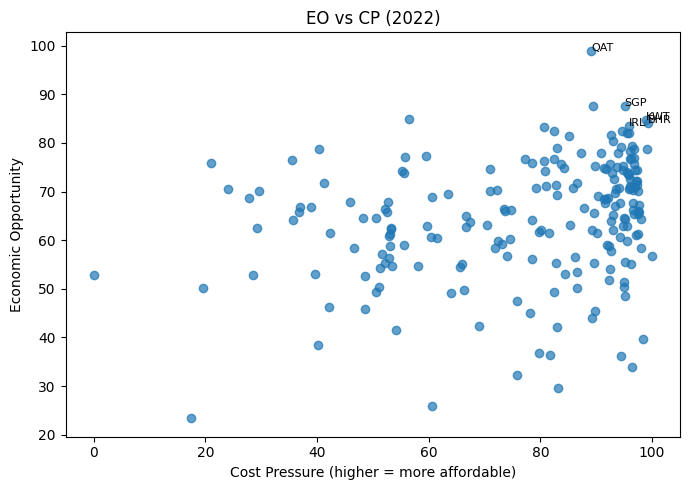

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(out["CP"], out["EO"], alpha=0.7)
plt.xlabel("Cost Pressure (higher = more affordable)")
plt.ylabel("Economic Opportunity")
plt.title("EO vs CP (2022)")

# Label top 5 ALI countries
best = out.nsmallest(5, "ALI_rank")
for _, r in best.iterrows():
    plt.text(r["CP"], r["EO"], r["iso3"], fontsize=8)

plt.tight_layout()
fig_path = "../outputs/figures/scatter_eo_vs_cp.png"
plt.savefig(fig_path, dpi=200)
fig_path

In [12]:
from scipy.stats import spearmanr

# Alternative weights: cost pressure emphasized
w2 = {"CP": 0.4, "EO": 0.3, "QOL": 0.3}

out2 = out.copy()
out2["ALI_alt"] = w2["CP"]*out2["CP"] + w2["EO"]*out2["EO"] + w2["QOL"]*out2["QOL"]
out2["rank_alt"] = out2["ALI_alt"].rank(ascending=False, method="min").astype(int)

rho = spearmanr(out["ALI_rank"], out2["rank_alt"]).statistic
rho

np.float64(0.9960066249539934)

'../outputs/figures/rank_sensitivity.png'

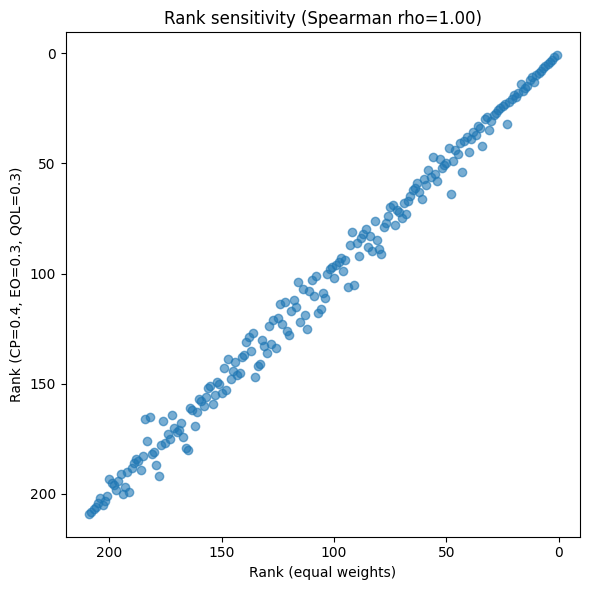

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(out["ALI_rank"], out2["rank_alt"], alpha=0.6)
plt.xlabel("Rank (equal weights)")
plt.ylabel("Rank (CP=0.4, EO=0.3, QOL=0.3)")
plt.title(f"Rank sensitivity (Spearman rho={rho:.2f})")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = "../outputs/figures/rank_sensitivity.png"
plt.savefig(fig_path, dpi=200)
fig_path

In [14]:
out["CP"].describe()

count    209.000000
mean      77.182337
std       21.488178
min        0.000000
25%       60.671949
50%       85.165418
75%       94.864611
max      100.000000
Name: CP, dtype: float64